# 01 — Trace one control step

Predict what changes when you write one actuator target, then inspect the state before and after physics steps.

This is the first entry in [the learning route](../../LEARNING.md). No RL or PPO implementation is supplied. It uses the canonical simulation core without a socket server or controller. A separate viewer replays the recorded treatment at interpretation time.

The cells run normally. Run All executes the experiment. In practice mode, discuss your first attempt with your pair programmer before advancing to the measurements. No form or code switch is required.

## Setup
From the `spider` repository root, install `requirements-learning.txt` and start `python -m jupyter lab`. Use that Python environment as the kernel. This notebook supports a kernel working directory at the repo root or in `notebooks/`.

The simulation dependencies are pinned in `requirements.txt`. The setup below prints installed package versions. Record those versions with any later comparison.

In [1]:
from pathlib import Path
from importlib.metadata import version
import sys

candidates = (Path.cwd(), *Path.cwd().parents)
REPO_ROOT = next(
    (path for path in candidates if (path / "spider" / "simulation.py").is_file()
     and (path / "model" / "spider.xml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Start the kernel in the repository or lab/notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import mujoco
import numpy as np
import matplotlib.pyplot as plt
from spider.simulation import load_model, measured_state, neutral_targets, reset, set_targets, step

print("Repository:", REPO_ROOT)
print("Python:", sys.version.split()[0])
print({name: version(name) for name in ("mujoco", "numpy", "matplotlib")})

Repository: C:\Users\haidm\Desktop\robotics\spider
Python: 3.12.10
{'mujoco': '3.11.0', 'numpy': '2.2.4', 'matplotlib': '3.11.1'}


## Try one control step

Use the physical picture: gravity, ground contact forces, joint torques, and actuator response.

Discuss what you expect to change when a target is written, and what needs a physics step. Code, a sketch, or a conversational explanation can be your first attempt. Leave uncertainty visible; there is no required prediction field.

Choose the actuator, target offset, and observation window below.

In [2]:
ACTUATOR_NAME = "front_left_hip_motor"
TARGET_OFFSET_RAD = 0.4
PHYSICS_STEPS = 500  # Observation window, not a policy-rate decision.


### 2. Prepare raw state capture
These helpers only define setup. The experiment creates a fresh model and state each time it runs. It resolves the selected joint through the actuator transmission instead of assuming an index.

Angles and targets use radians. Angular velocity uses radians per second. Time uses seconds. The selected hinge actuator force uses newton metres. The raw arrays retain MuJoCo's sampling order. Do not treat every derived field as a freshly recomputed post-step value without checking that order in the core.

In [3]:
from spider.recording import TreatmentReplay

def capture_raw(model, data, actuator_id, joint_id, label):
    position_address = model.jnt_qposadr[joint_id]
    velocity_address = model.jnt_dofadr[joint_id]
    return {
        "label": label,
        "time_s": float(data.time),
        "target_rad": float(data.ctrl[actuator_id]),
        "joint_position_rad": float(data.qpos[position_address]),
        "joint_velocity_rad_s": float(data.qvel[velocity_address]),
        "actuator_torque_nm": float(data.actuator_force[actuator_id]),
    }


def run_target_experiment():
    if not isinstance(PHYSICS_STEPS, int) or PHYSICS_STEPS < 1:
        raise ValueError("PHYSICS_STEPS must be a positive integer.")
    model = load_model()
    data = mujoco.MjData(model)
    reset(model, data)
    actuator_id = model.actuator(ACTUATOR_NAME).id
    joint_id = int(model.actuator_trnid[actuator_id, 0])
    targets = np.array(neutral_targets(), dtype=float)
    targets[actuator_id] += TARGET_OFFSET_RAD
    lower, upper = model.actuator_ctrlrange[actuator_id]
    if not np.isfinite(targets[actuator_id]) or not lower <= targets[actuator_id] <= upper:
        raise ValueError("Choose a finite target inside the actuator control range.")
    replay = TreatmentReplay(model, f"{ACTUATOR_NAME} | offset {TARGET_OFFSET_RAD:+g} rad | {PHYSICS_STEPS} steps", actuator_name=ACTUATOR_NAME)
    replay.capture(data)
    snapshots = [capture_raw(model, data, actuator_id, joint_id, "reset")]
    set_targets(data, targets)
    snapshots.append(capture_raw(model, data, actuator_id, joint_id, "target written"))
    replay.capture(data)
    for index in range(PHYSICS_STEPS):
        step(model, data)
        replay.capture(data)
        snapshots.append(capture_raw(model, data, actuator_id, joint_id, f"step {index + 1}"))
    return snapshots, measured_state(model, data), float(model.opt.timestep), replay

## Inspect the measurements

After discussing your attempt, run this cell. Start with the first three records. Compare your expectation with the raw values before interpreting the longer trace.

In [4]:
snapshots, final_state, timestep_s, treatment_replay = run_target_experiment()
print("Physics timestep (s):", timestep_s)
for snapshot in snapshots[:3]:
    print(snapshot)


Physics timestep (s): 0.002
{'label': 'reset', 'time_s': 0.0, 'target_rad': -0.2, 'joint_position_rad': -0.2, 'joint_velocity_rad_s': 0.0, 'actuator_torque_nm': 0.0}
{'label': 'target written', 'time_s': 0.0, 'target_rad': 0.2, 'joint_position_rad': -0.2, 'joint_velocity_rad_s': 0.0, 'actuator_torque_nm': 0.0}
{'label': 'step 1', 'time_s': 0.002, 'target_rad': 0.2, 'joint_position_rad': -0.19518174593010412, 'joint_velocity_rad_s': 2.4091270349479488, 'actuator_torque_nm': 120.0}


### 4. Compare the command and measured angle
The plot shows the selected joint only. It does not establish whole-body stability or explain causality. Use the raw records to distinguish the target write from the first physics step.

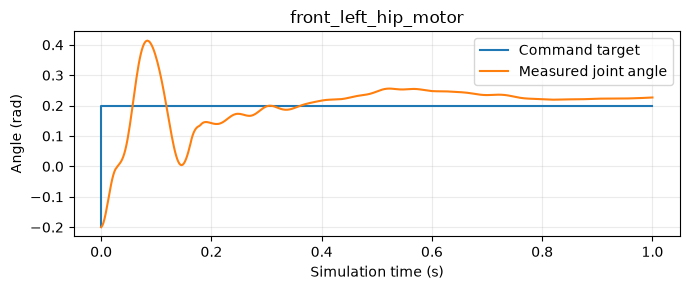

In [5]:
times = [row["time_s"] for row in snapshots]
fig, axis = plt.subplots(figsize=(7, 3))
axis.plot(times, [row["target_rad"] for row in snapshots], label="Command target")
axis.plot(times, [row["joint_position_rad"] for row in snapshots], label="Measured joint angle")
axis.set(xlabel="Simulation time (s)", ylabel="Angle (rad)", title=ACTUATOR_NAME)
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Watch the recorded treatment
Open the native simulator before interpreting the measurements. This replays the exact recorded states with the current visual model. Playback loops at 0.25x speed with a one-second hold at the end. Display speed does not change the experiment. The window has the treatment label and simulation time. Close it when finished.

The close-up includes a translucent starting-pose reference and a measured joint-angle trace. The ghost is not a separate control experiment.


In [6]:
viewer_process = treatment_replay.launch(REPO_ROOT / "telemetry" / "notebook-replays", speed=0.25)


Viewer opened (PID 34680). Recorded states: C:\Users\haidm\Desktop\robotics\spider\telemetry\notebook-replays\treatment-hy5j6yy8


## Review your attempt

Discuss one observation that supports or changes your expectation. Trace the target write and physics step in `simulation.py`, then connect the actuator to its joint in the model.

Use that feedback to choose the next small change. Notes are optional; the conversation can carry the iteration. Running these cells alone does not establish understanding.

## Next Steps
Read [LEARNING.md](../../LEARNING.md) with your pair programmer. Define observations, reward components, failure conditions, and policy timing together before training.

`learning_env.LearningSimulation` provides `reset()` and `step(target_offsets_rad, physics_steps=...)`. It accepts offsets around the neutral targets and returns `MeasuredState`. It is a physics adapter, not a Gym environment or a trainer. It does not choose reward, termination, or policy timing for you.

You will write the RL loop and PPO with PyTorch. Keep the first explanation and implementation attempt yours.